In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# FINAL_results_NoDPD_lspan_trained_1.csv
# FINAL_results_DPD_WH_BER_vs_Lspan.csv
# FINAL_results_DPD_NN_lspan_trained_1.csv
# FINAL_results_DPD_MP_BER_vs_Spans.csv


FINAL DATA (Mean, SD, RSD %, p-value):

    lspan  mean_BER  std_BER  RSD_percent      Case  p_value
0      10    0.0004      0.0       4.8241  Baseline      NaN
1      20    0.0003      0.0       3.3818  Baseline      NaN
2      40    0.0002      0.0       7.7305  Baseline      NaN
3      80    0.0002      0.0       7.1568  Baseline      NaN
4      10    0.0002      0.0       6.6812        ML   0.0000
5      20    0.0001      0.0       8.4633        ML   0.0000
6      40    0.0001      0.0       8.6030        ML   0.0000
7      80    0.0001      0.0      10.0015        ML   0.0000
8      10    0.0003      0.0       3.4934        MP   0.0001
9      20    0.0002      0.0       3.2616        MP   0.0000
10     40    0.0001      0.0       4.3768        MP   0.0003
11     80    0.0001      0.0       4.9947        MP   0.0001
12     10    0.0003      0.0       1.2809        WH   0.0150
13     20    0.0002      0.0       4.2704        WH   0.0002
14     40    0.0002      0.0       3.1610   

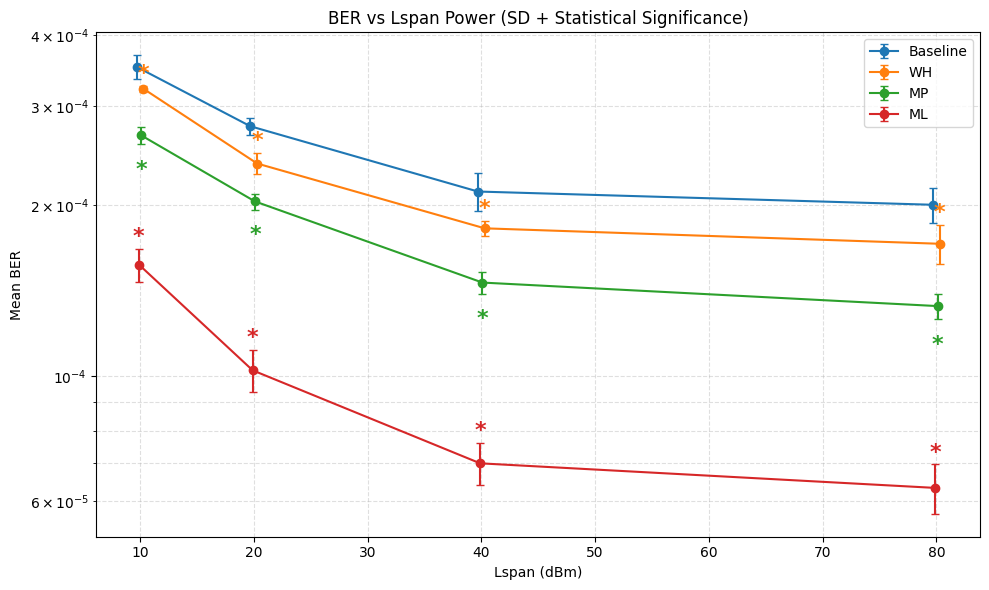

In [3]:
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import ttest_ind
import pandas as pd

# -----------------------------
# File paths
# -----------------------------
FILES = {
    "Baseline": "FINAL_results_NoDPD_lspan_trained_1.csv",
    "ML": "FINAL_results_DPD_NN_lspan_trained_1.csv",
    "MP": "FINAL_results_DPD_MP_BER_vs_Spans.csv",
    "WH": "FINAL_results_DPD_WH_BER_vs_Lspan.csv",
}

BASE_DIR = Path.cwd()

# -----------------------------
# Load data
# -----------------------------
dfs = {}
for case, file in FILES.items():
    dfs[case] = pd.read_csv(BASE_DIR / file)

# -----------------------------
# Compute mean, SD, RSD (%)
# -----------------------------
summaries = []

for case, df in dfs.items():
    summary = (
        df.groupby("lspan")
        .agg(
            mean_BER=("BER", "mean"),
            std_BER=("BER", "std"),
        )
        .reset_index()
    )

    # RSD in %
    summary["RSD_percent"] = (summary["std_BER"] / summary["mean_BER"]) * 100
    summary["Case"] = case
    summaries.append(summary)

summary_df = pd.concat(summaries)

# -----------------------------
# T-tests vs baseline
# -----------------------------
results = []
spans = sorted(dfs["Baseline"]["lspan"].unique())

for span in spans:
    baseline_vals = dfs["Baseline"][dfs["Baseline"]["lspan"] == span]["BER"]

    for method in ["ML", "MP", "WH"]:
        method_vals = dfs[method][dfs[method]["lspan"] == span]["BER"]

        _, p_value = ttest_ind(baseline_vals, method_vals, equal_var=False)

        results.append({
            "lspan": span,
            "Case": method,
            "p_value": p_value
        })

pvals_df = pd.DataFrame(results)

# -----------------------------
# Merge results
# -----------------------------
final_df = summary_df.merge(
    pvals_df,
    on=["lspan", "Case"],
    how="left"
)

print("\nFINAL DATA (Mean, SD, RSD %, p-value):\n")
print(final_df.sort_values(["Case", "lspan"]).round(4))

# -----------------------------
# RSD (%) min and max
# -----------------------------
min_row = final_df.loc[final_df["RSD_percent"].idxmin()]
max_row = final_df.loc[final_df["RSD_percent"].idxmax()]

print("\nRSD (%) Summary:")
print(f"Lowest RSD (%): {min_row['RSD_percent']:.4f} (Case={min_row['Case']}, lspan={min_row['lspan']})")
print(f"Highest RSD (%): {max_row['RSD_percent']:.4f} (Case={max_row['Case']}, lspan={max_row['lspan']})")

# -----------------------------
# Global RSD (%)
# -----------------------------
all_values = pd.concat([df["BER"] for df in dfs.values()])
global_mean = all_values.mean()
global_std = all_values.std()

global_rsd_percent = (
    (global_std / global_mean) * 100 if global_mean != 0 else float("nan")
)

print("\nGlobal RSD (%):", round(global_rsd_percent, 4))

# -----------------------------
# Improvement Factor (lspan 10 & 80)
# -----------------------------
target_lspans = [10, 80]
improvement_results = []

for span in target_lspans:
    baseline_mean = final_df[
        (final_df["Case"] == "Baseline") & (final_df["lspan"] == span)
    ]["mean_BER"].values

    if len(baseline_mean) == 0:
        continue

    baseline_mean = baseline_mean[0]

    for method in ["ML", "MP", "WH"]:
        method_mean = final_df[
            (final_df["Case"] == method) & (final_df["lspan"] == span)
        ]["mean_BER"].values

        if len(method_mean) == 0:
            continue

        method_mean = method_mean[0]

        improvement = baseline_mean / method_mean if method_mean != 0 else float("nan")

        improvement_results.append({
            "lspan": span,
            "Case": method,
            "Improvement_Factor": improvement
        })

improvement_df = pd.DataFrame(improvement_results)

print("\nImprovement Factor (Baseline / Method):\n")
print(improvement_df.round(4))

# -----------------------------
# Log10 BER Ratio (lspan 80 / 40) - Publication Metric
# -----------------------------
import numpy as np

log_ratio_results = []

for case in ["WH", "MP"]:
    ber_40 = final_df[
        (final_df["Case"] == case) & (final_df["lspan"] == 40)
    ]["mean_BER"].values

    ber_80 = final_df[
        (final_df["Case"] == case) & (final_df["lspan"] == 80)
    ]["mean_BER"].values

    if len(ber_40) == 0 or len(ber_80) == 0:
        continue

    ber_40 = ber_40[0]
    ber_80 = ber_80[0]

    if ber_40 > 0 and ber_80 > 0:
        log_ratio = np.log10(ber_80 / ber_40)
    else:
        log_ratio = float("nan")

    log_ratio_results.append({
        "Case": case,
        "BER_40": ber_40,
        "BER_80": ber_80,
        "log10(80/40)": log_ratio
    })

log_ratio_df = pd.DataFrame(log_ratio_results)

print("\nLog10 BER Ratio (lspan 80 / 40):\n")
print(log_ratio_df.round(4))

# -----------------------------
# Plot (SD error bars + significance)
# -----------------------------
offsets = {
    "Baseline": -0.3,
    "ML": -0.1,
    "MP": 0.1,
    "WH": 0.3,
}

colors = {
    "Baseline": "tab:blue",
    "ML": "tab:red",
    "MP": "tab:green",
    "WH": "tab:orange",
}

plt.figure(figsize=(10, 6))

for case in ["Baseline", "WH", "MP", "ML"]:
    data = final_df[final_df["Case"] == case].sort_values("lspan")

    x = data["lspan"] + offsets[case]

    plt.errorbar(
        x,
        data["mean_BER"],
        yerr=data["std_BER"],
        marker="o",
        capsize=3,
        label=case,
        color=colors[case],
    )

    # significance stars
    if case != "Baseline":
        for _, row in data.iterrows():
            if pd.notna(row["p_value"]) and row["p_value"] < 0.05:

                mean = row["mean_BER"]
                std = row["std_BER"]

                if case in ["ML", "WH"]:
                    y_pos = (mean + std) * 1.05
                else:  # MP
                    y_pos = max((mean - std) * 0.9, 1e-12)

                plt.text(
                    row["lspan"] + offsets[case],
                    y_pos,
                    "*",
                    color=colors[case],
                    ha="center",
                    va="center",
                    fontsize=16,
                    fontweight="bold",
                )

plt.yscale("log")
plt.xlabel("Lspan (dBm)")
plt.ylabel("Mean BER")
plt.title("BER vs Lspan Power (SD + Statistical Significance)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()

plt.savefig("ber_sd_with_significance_lspan.png", dpi=300)
plt.show()


Relative BER vs Baseline (lspan = 10, 80):

   lspan Case  Relative_BER_vs_Baseline
0     10   ML                    0.4471
1     10   MP                    0.7567
2     10   WH                    0.9147
3     80   ML                    0.3158
4     80   MP                    0.6620
5     80   WH                    0.8532

FINAL DATA (Mean, SD, RSD %, p-value):

    lspan  mean_BER  std_BER  RSD_percent      Case  p_value
0      10    0.0004      0.0       4.8241  Baseline      NaN
1      20    0.0003      0.0       3.3818  Baseline      NaN
2      40    0.0002      0.0       7.7305  Baseline      NaN
3      80    0.0002      0.0       7.1568  Baseline      NaN
4      10    0.0002      0.0       6.6812        ML   0.0000
5      20    0.0001      0.0       8.4633        ML   0.0000
6      40    0.0001      0.0       8.6030        ML   0.0000
7      80    0.0001      0.0      10.0015        ML   0.0000
8      10    0.0003      0.0       3.4934        MP   0.0001
9      20    0.0002     

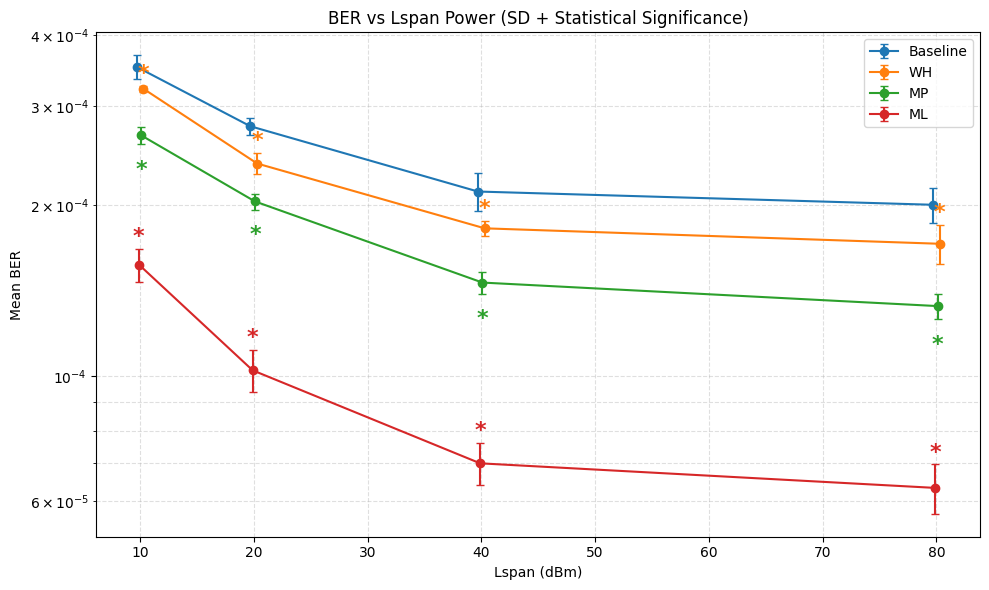

In [4]:
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import ttest_ind
import pandas as pd

FILES = {
    "Baseline": "FINAL_results_NoDPD_lspan_trained_1.csv",
    "ML": "FINAL_results_DPD_NN_lspan_trained_1.csv",
    "MP": "FINAL_results_DPD_MP_BER_vs_Spans.csv",
    "WH": "FINAL_results_DPD_WH_BER_vs_Lspan.csv",
}

BASE_DIR = Path.cwd()

# -----------------------------
# Load data
# -----------------------------
dfs = {}

for case, file in FILES.items():
    df = pd.read_csv(BASE_DIR / file)
    dfs[case] = df

# -----------------------------
# Compute mean + SD + RSD (%)
# -----------------------------
summaries = []

for case, df in dfs.items():
    summary = (
        df.groupby("lspan")
        .agg(
            mean_BER=("BER", "mean"),
            std_BER=("BER", "std"),
        )
        .reset_index()
    )

    # ✅ RSD as percentage
    summary["RSD_percent"] = (summary["std_BER"] / summary["mean_BER"]) * 100

    summary["Case"] = case
    summaries.append(summary)

summary_df = pd.concat(summaries)

# -----------------------------
# T-tests vs baseline
# -----------------------------
results = []

spans = sorted(dfs["Baseline"]["lspan"].unique())

for span in spans:

    baseline_vals = dfs["Baseline"][
        dfs["Baseline"]["lspan"] == span
    ]["BER"]

    for method in ["ML", "MP", "WH"]:

        method_vals = dfs[method][
            dfs[method]["lspan"] == span
        ]["BER"]

        _, p_value = ttest_ind(baseline_vals, method_vals, equal_var=False)

        results.append({
            "lspan": span,
            "Case": method,
            "p_value": p_value
        })

pvals_df = pd.DataFrame(results)

# Merge everything
final_df = summary_df.merge(
    pvals_df,
    on=["lspan", "Case"],
    how="left"
)

# -----------------------------
# Relative BER vs Baseline (lspan = 10 and 80)
# -----------------------------
target_lspans = [10, 80]

rel_results = []

for span in target_lspans:
    baseline_mean = final_df[
        (final_df["Case"] == "Baseline") & (final_df["lspan"] == span)
    ]["mean_BER"].values

    if len(baseline_mean) == 0:
        continue

    baseline_mean = baseline_mean[0]

    for method in ["ML", "MP", "WH"]:
        method_mean = final_df[
            (final_df["Case"] == method) & (final_df["lspan"] == span)
        ]["mean_BER"].values

        if len(method_mean) == 0:
            continue

        method_mean = method_mean[0]

        rel_ber = method_mean / baseline_mean if baseline_mean != 0 else float("nan")

        rel_results.append({
            "lspan": span,
            "Case": method,
            "Relative_BER_vs_Baseline": rel_ber
        })

rel_df = pd.DataFrame(rel_results)

print("\nRelative BER vs Baseline (lspan = 10, 80):\n")
print(rel_df.round(4))

print("\nFINAL DATA (Mean, SD, RSD %, p-value):\n")
print(final_df.sort_values(["Case", "lspan"]).round(4))

# -----------------------------
# RSD (%) min and max
# -----------------------------
min_rsd = final_df["RSD_percent"].min()
max_rsd = final_df["RSD_percent"].max()

min_row = final_df.loc[final_df["RSD_percent"].idxmin()]
max_row = final_df.loc[final_df["RSD_percent"].idxmax()]

print("\nRSD (%) Summary:")
print(f"Lowest RSD (%): {min_rsd:.4f} (Case={min_row['Case']}, lspan={min_row['lspan']})")
print(f"Highest RSD (%): {max_rsd:.4f} (Case={max_row['Case']}, lspan={max_row['lspan']})")

# -----------------------------
# Global RSD (%)
# -----------------------------
all_values = pd.concat([df["BER"] for df in dfs.values()])
global_mean = all_values.mean()
global_std = all_values.std()

global_rsd_percent = (
    (global_std / global_mean) * 100 if global_mean != 0 else float("nan")
)

print("\nGlobal RSD (%):", round(global_rsd_percent, 4))

# -----------------------------
# Plot (SD error bars + stars)
# -----------------------------
offsets = {
    "Baseline": -0.3,
    "ML": -0.1,
    "MP": 0.1,
    "WH": 0.3,
}

colors = {
    "Baseline": "tab:blue",
    "ML": "tab:red",
    "MP": "tab:green",
    "WH": "tab:orange",
}

plt.figure(figsize=(10, 6))

for case in ["Baseline", "WH", "MP", "ML"]:
    data = final_df[final_df["Case"] == case].sort_values("lspan")

    x = data["lspan"] + offsets[case]

    plt.errorbar(
        x,
        data["mean_BER"],
        yerr=data["std_BER"],
        marker="o",
        capsize=3,
        label=case,
        color=colors[case],
    )

    # Add stars for statistically significant DPD methods only
    if case != "Baseline":
        for _, row in data.iterrows():
            if pd.notna(row["p_value"]) and row["p_value"] < 0.05:

                mean = row["mean_BER"]
                std = row["std_BER"]

                if case in ["ML", "WH"]:
                    y_pos = (mean + std) * 1.05
                elif case == "MP":
                    y_pos = max((mean - std) * 0.9, 1e-12)

                plt.text(
                    row["lspan"] + offsets[case],
                    y_pos,
                    "*",
                    color=colors[case],
                    ha="center",
                    va="center",
                    fontsize=16,
                    fontweight="bold",
                )

plt.yscale("log")
plt.xlabel("Lspan (dBm)")
plt.ylabel("Mean BER")
plt.title("BER vs Lspan Power (SD + Statistical Significance)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()

plt.savefig("ber_sd_with_significance_lspan.png", dpi=300)
plt.show()


FINAL DATA (Mean, SD, p-value):

    lspan  mean_BER   std_BER      Case       p_value
0      10  0.000352  0.000017  Baseline           NaN
1      20  0.000276  0.000009  Baseline           NaN
2      40  0.000212  0.000016  Baseline           NaN
3      80  0.000201  0.000014  Baseline           NaN
4      10  0.000157  0.000011        ML  1.883988e-07
5      20  0.000102  0.000009        ML  1.567932e-09
6      40  0.000070  0.000006        ML  8.329503e-06
7      80  0.000063  0.000006        ML  2.693192e-06
8      10  0.000266  0.000009        MP  5.017159e-05
9      20  0.000203  0.000007        MP  1.542000e-06
10     40  0.000146  0.000006        MP  3.357528e-04
11     80  0.000133  0.000007        MP  1.069045e-04
12     10  0.000322  0.000004        WH  1.495476e-02
13     20  0.000237  0.000010        WH  2.363377e-04
14     40  0.000182  0.000006        WH  1.280075e-02
15     80  0.000171  0.000014        WH  1.058906e-02


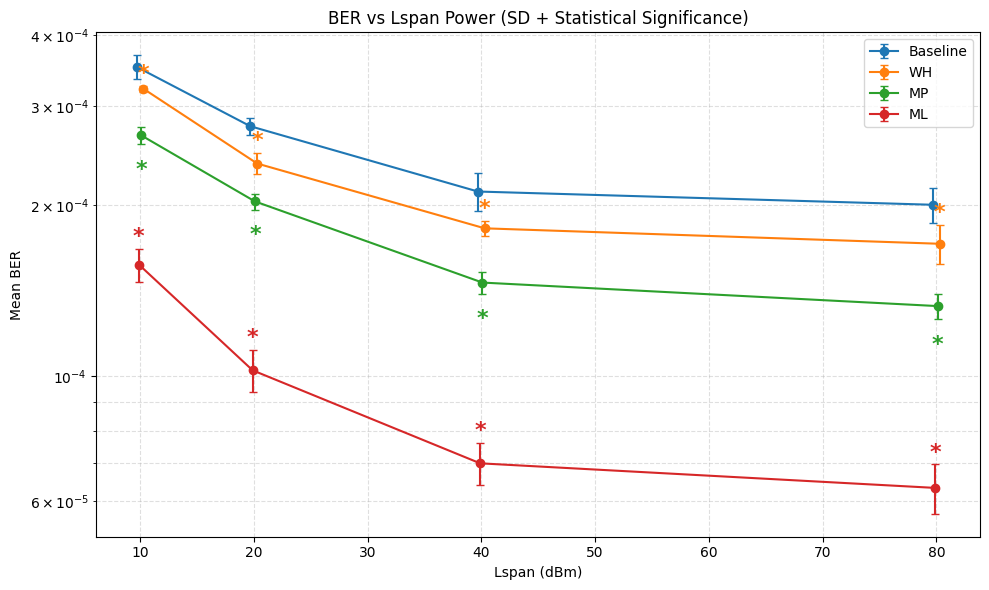

In [5]:
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import ttest_ind

FILES = {
    "Baseline": "FINAL_results_NoDPD_lspan_trained_1.csv",
    "ML": "FINAL_results_DPD_NN_lspan_trained_1.csv",
    "MP": "FINAL_results_DPD_MP_BER_vs_Spans.csv",
    "WH": "FINAL_results_DPD_WH_BER_vs_Lspan.csv",
}

BASE_DIR = Path.cwd()

# -----------------------------
# Load data
# -----------------------------
dfs = {}

for case, file in FILES.items():
    df = pd.read_csv(BASE_DIR / file)

    dfs[case] = df

# -----------------------------
# Compute mean + SD
# -----------------------------
summaries = []
import pandas as pd

for case, df in dfs.items():
    summary = (
        df.groupby("lspan")
        .agg(
            mean_BER=("BER", "mean"),
            std_BER=("BER", "std"),
        )
        .reset_index()
    )

    summary["Case"] = case
    summaries.append(summary)

summary_df = pd.concat(summaries)

# -----------------------------
# T-tests vs baseline
# -----------------------------
results = []

spans = sorted(dfs["Baseline"]["lspan"].unique())

for span in spans:

    baseline_vals = dfs["Baseline"][
        dfs["Baseline"]["lspan"] == span
    ]["BER"]

    for method in ["ML", "MP", "WH"]:

        method_vals = dfs[method][
            dfs[method]["lspan"] == span
        ]["BER"]

        _, p_value = ttest_ind(baseline_vals, method_vals, equal_var=False)

        results.append({
            "lspan": span,
            "Case": method,
            "p_value": p_value
        })

pvals_df = pd.DataFrame(results)

# Merge everything
final_df = summary_df.merge(
    pvals_df,
    on=["lspan", "Case"],
    how="left"
)

print("\nFINAL DATA (Mean, SD, p-value):\n")
print(final_df.sort_values(["Case", "lspan"]))

# -----------------------------
# Plot (SD error bars + stars)
# -----------------------------
offsets = {
    "Baseline": -0.3,
    "ML": -0.1,
    "MP": 0.1,
    "WH": 0.3,
}

colors = {
    "Baseline": "tab:blue",
    "ML": "tab:red",
    "MP": "tab:green",
    "WH": "tab:orange",
}

y_offsets = {
    "ML": 1.1,   # above
    "WH": 1.1,   # above
    "MP": 0.8,   # below
}

plt.figure(figsize=(10, 6))

for case in ["Baseline", "WH", "MP", "ML"]:
    data = final_df[final_df["Case"] == case].sort_values("lspan")

    x = data["lspan"] + offsets[case]

    plt.errorbar(
        x,
        data["mean_BER"],
        yerr=data["std_BER"],
        marker="o",
        capsize=3,
        label=case,
        color=colors[case],
    )

    # Add stars for statistically significant DPD methods only
    if case != "Baseline":
        for _, row in data.iterrows():
            if pd.notna(row["p_value"]) and row["p_value"] < 0.05:

                mean = row["mean_BER"]
                std = row["std_BER"]

                if case in ["ML", "WH"]:  # stars ABOVE
                    y_pos = (mean + std) * 1.05

                elif case == "MP":        # stars BELOW
                    y_pos = max((mean - std) * 0.9, 1e-12)  # avoid log issues

                plt.text(
                    row["lspan"] + offsets[case],
                    y_pos,
                    "*",
                    color=colors[case],
                    ha="center",
                    va="center",
                    fontsize=16,
                    fontweight="bold",
                )

plt.yscale("log")
plt.xlabel("Lspan (dBm)")
plt.ylabel("Mean BER")
plt.title("BER vs Lspan Power (SD + Statistical Significance)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()

plt.savefig("ber_sd_with_significance_lspan.png", dpi=300)
plt.show()


Plotted Mean BER Values:
        Case  lspan  Spans  mean_BER   std_BER
0   Baseline     10    8.0  0.000352  0.000017
1   Baseline     20    4.0  0.000276  0.000009
2   Baseline     40    2.0  0.000212  0.000016
3   Baseline     80    1.0  0.000201  0.000014
12        ML     10    8.0  0.000157  0.000011
13        ML     20    4.0  0.000102  0.000009
14        ML     40    2.0  0.000070  0.000006
15        ML     80    1.0  0.000063  0.000006
8         MP     10    8.0  0.000266  0.000009
9         MP     20    4.0  0.000203  0.000007
10        MP     40    2.0  0.000146  0.000006
11        MP     80    1.0  0.000133  0.000007
4         WH     10    8.0  0.000322  0.000004
5         WH     20    4.0  0.000237  0.000010
6         WH     40    2.0  0.000182  0.000006
7         WH     80    1.0  0.000171  0.000014


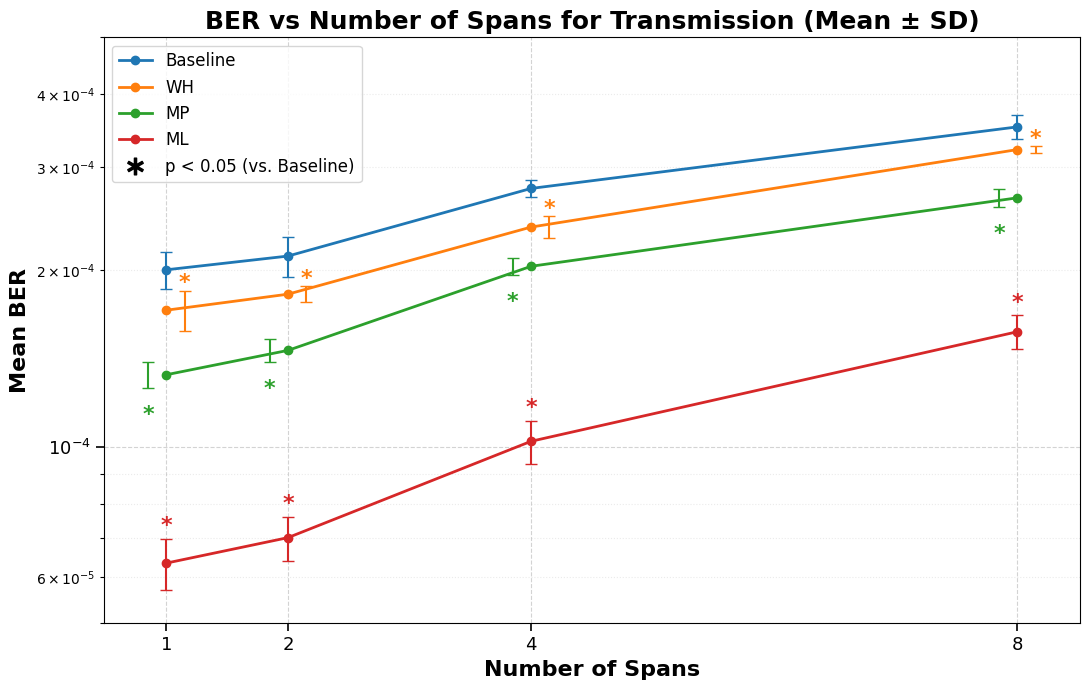

In [6]:
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd

plot_data = []

# -----------------------------
# Plot settings
# -----------------------------
offsets = {
    "Baseline": 0,
    "ML": 0,
    "MP": -0.15,
    "WH": 0.15,
}

colors = {
    "Baseline": "tab:blue",
    "ML": "tab:red",
    "MP": "tab:green",
    "WH": "tab:orange",
}

plt.figure(figsize=(11, 7))
ax = plt.gca()

# -----------------------------
# Plot curves
# -----------------------------
for case in ["Baseline", "WH", "MP", "ML"]:
    data = final_df[final_df["Case"] == case].sort_values("lspan")

    # ✅ Collect EXACT plotted values
    for _, row in data.iterrows():
        plot_data.append({
            "Case": case,
            "lspan": row["lspan"],
            "Spans": 80 / row["lspan"],   # x-axis used in plot
            "mean_BER": row["mean_BER"],
            "std_BER": row["std_BER"]
        })

    x_true = 80 / data["lspan"]
    x_err = x_true + offsets[case]

    ax.plot(
        x_true,
        data["mean_BER"],
        marker="o",
        markersize=6,
        linewidth=2,
        label=case,
        color=colors[case],
    )

    ax.errorbar(
        x_err,
        data["mean_BER"],
        yerr=data["std_BER"],
        fmt="none",
        capsize=4,
        elinewidth=1.5,
        color=colors[case],
    )

    # -----------------------------
    # Significance stars
    # -----------------------------
    if case != "Baseline":
        for _, row in data.iterrows():
            if pd.notna(row["p_value"]) and row["p_value"] < 0.05:

                mean = row["mean_BER"]
                std = row["std_BER"]

                if case == "ML":
                    y_pos = (mean + std) * 1.05
                elif case == "WH":
                    y_pos = (mean + std) * 1.03
                elif case == "MP":
                    y_pos = max((mean - std) * 0.9, 1e-12)

                plt.text(
                    (80 / row["lspan"]) + offsets[case],
                    y_pos,
                    "*",
                    color=colors[case],
                    ha="center",
                    va="center",
                    fontsize=16,
                    fontweight="bold",
                )

# ✅ Create dataframe AFTER loop
plot_df = pd.DataFrame(plot_data)

# ✅ Save exact plotted values
plot_df.to_csv("mean_ber_values_used_in_plot.csv", index=False)

# ✅ Print nicely
print("\nPlotted Mean BER Values:")
print(plot_df.sort_values(["Case", "lspan"]))

# -----------------------------
# Axis formatting
# -----------------------------
ax.set_yscale("log")
ax.set_ylim(5e-5, 5e-4)

ax.set_xlabel("Number of Spans", fontsize=16, fontweight="bold")
ax.set_ylabel("Mean BER", fontsize=16, fontweight="bold")
ax.set_title(
    "BER vs Number of Spans for Transmission (Mean ± SD)",
    fontsize=18,
    fontweight="bold"
)

ax.set_xticks(sorted(80 / final_df["lspan"].unique()))

# -----------------------------
# Styling
# -----------------------------
ax.tick_params(axis="both", which="major", labelsize=13, width=1.2, length=6)
ax.tick_params(axis="both", which="minor", width=0.8, length=3)

ax.grid(True, which="major", linestyle="--", alpha=0.55)
ax.grid(True, which="minor", linestyle=":", alpha=0.25)

# -----------------------------
# Legend
# -----------------------------
handles, labels = ax.get_legend_handles_labels()

star_handle = Line2D(
    [],
    [],
    color="black",
    marker=r"$\ast$",
    linestyle="None",
    markersize=12,
    label="p < 0.05 (vs. Baseline)"
)

handles.append(star_handle)

ax.legend(
    handles=handles,
    fontsize=12,
    title_fontsize=13,
    loc="upper left"
)

plt.tight_layout()
plt.savefig("ber_sd_with_significance_clean_80_over_lspan.png", dpi=300)
plt.show()

# I tried other plots below incase any where useful


================ SUMMARY (MEAN ± CI) ================

    Case  lspan  mean_BER  std_BER  CI_lower  CI_upper  N
Baseline     10  0.000352 0.000017  0.000331  0.000373  5
Baseline     20  0.000276 0.000009  0.000265  0.000288  5
Baseline     40  0.000212 0.000016  0.000191  0.000232  5
Baseline     80  0.000201 0.000014  0.000183  0.000218  5
      NN     10  0.000157 0.000011  0.000144  0.000170  5
      NN     20  0.000102 0.000009  0.000091  0.000113  5
      NN     40  0.000070 0.000006  0.000063  0.000077  5
      NN     80  0.000063 0.000006  0.000055  0.000071  5
      MP     10  0.000266 0.000009  0.000255  0.000278  5
      MP     20  0.000203 0.000007  0.000195  0.000212  5
      MP     40  0.000146 0.000006  0.000138  0.000154  5
      MP     80  0.000133 0.000007  0.000125  0.000141  5
      WH     10  0.000322 0.000004  0.000317  0.000327  5
      WH     20  0.000237 0.000010  0.000225  0.000250  5
      WH     40  0.000182 0.000006  0.000175  0.000189  5
      WH     80 

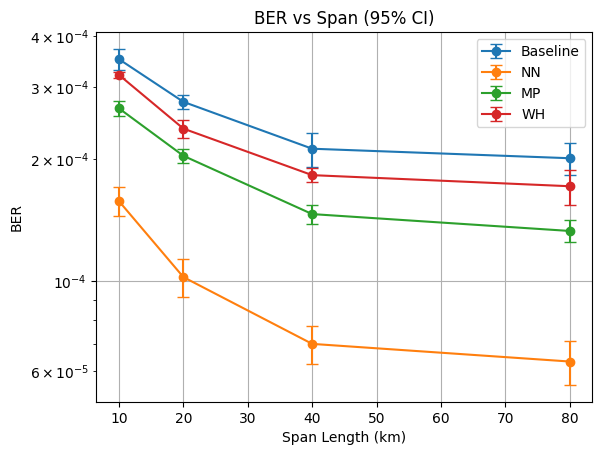

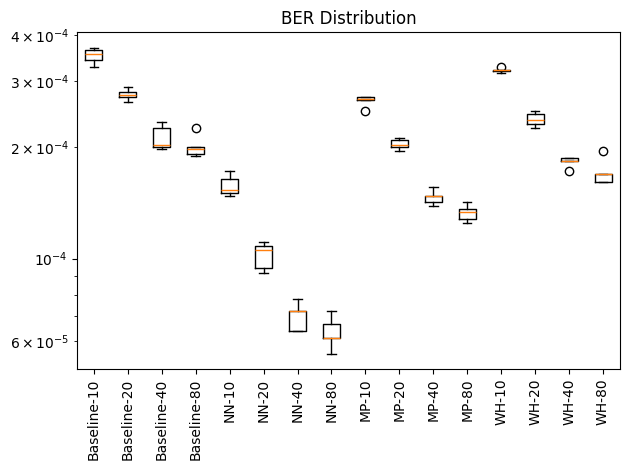

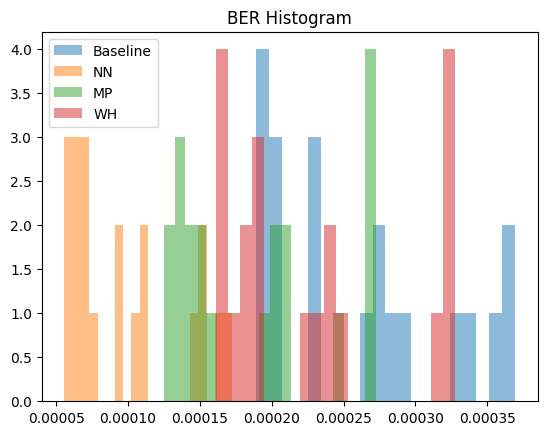


================ CORRELATION MATRICES ================


--- Baseline ---
              BER       SNR       EVM   Qfactor
BER      1.000000 -0.974760  0.976290 -0.997239
SNR     -0.974760  1.000000 -0.999845  0.975262
EVM      0.976290 -0.999845  1.000000 -0.975715
Qfactor -0.997239  0.975262 -0.975715  1.000000

--- NN ---
              BER       SNR       EVM   Qfactor
BER      1.000000 -0.963265  0.968401 -0.993121
SNR     -0.963265  1.000000 -0.999565  0.974666
EVM      0.968401 -0.999565  1.000000 -0.976947
Qfactor -0.993121  0.974666 -0.976947  1.000000

--- MP ---
              BER       SNR       EVM   Qfactor
BER      1.000000 -0.990220  0.991546 -0.996729
SNR     -0.990220  1.000000 -0.999792  0.991977
EVM      0.991546 -0.999792  1.000000 -0.991810
Qfactor -0.996729  0.991977 -0.991810  1.000000

--- WH ---
              BER       SNR       EVM   Qfactor
BER      1.000000 -0.978459  0.981050 -0.997080
SNR     -0.978459  1.000000 -0.999845  0.983477
EVM      0.981050 -0.9998

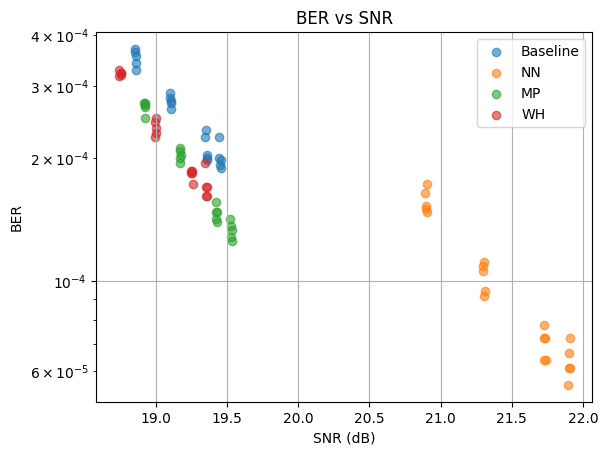


================ ERROR PROPAGATION (sample) ================

 lspan      BER  BER_error_propagated
    10 0.000317              0.005590
    10 0.000328              0.004815
    10 0.000322              0.018074
    10 0.000319              0.017150
    10 0.000322              0.001108
    10 0.000369              0.004155
    10 0.000364              0.003730
    10 0.000356              0.011057
    10 0.000328              0.000581
    10 0.000342              0.010080

================ ROC-STYLE RESULTS ================

 lspan  success
    10      1.0
    20      1.0
    40      1.0
    80      1.0


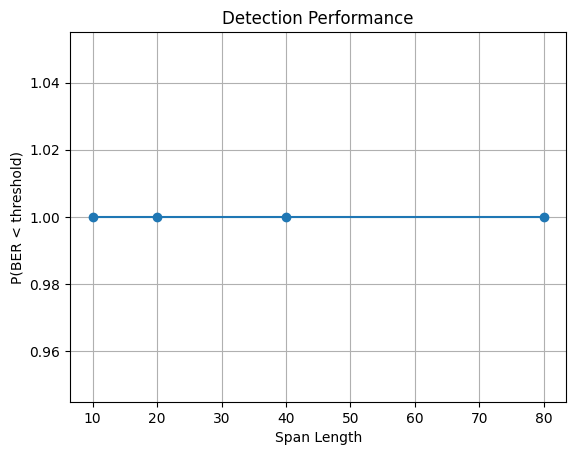

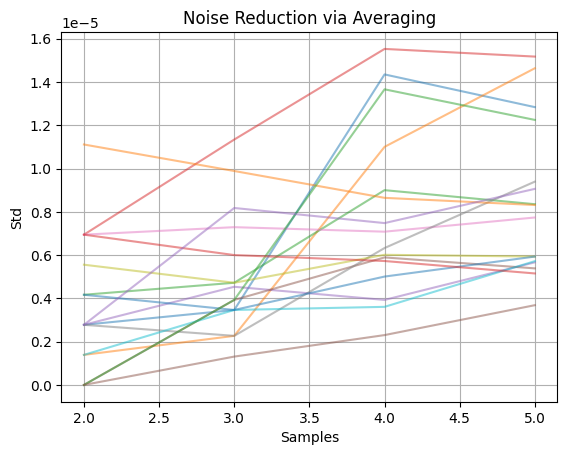


================ QUICK STATS CHECK ================


--- Baseline ---
       count      mean       std       min       25%       50%       75%       max
lspan                                                                             
10       5.0  0.000352  0.000017  0.000328  0.000342  0.000356  0.000364  0.000369
20       5.0  0.000276  0.000009  0.000264  0.000272  0.000275  0.000281  0.000289
40       5.0  0.000212  0.000016  0.000197  0.000200  0.000203  0.000225  0.000233
80       5.0  0.000201  0.000014  0.000189  0.000192  0.000197  0.000200  0.000225

--- NN ---
       count      mean       std       min       25%       50%       75%       max
lspan                                                                             
10       5.0  0.000157  0.000011  0.000147  0.000150  0.000153  0.000164  0.000172
20       5.0  0.000102  0.000009  0.000092  0.000094  0.000106  0.000108  0.000111
40       5.0  0.000070  0.000006  0.000064  0.000064  0.000072  0.000072  0.000078
80 

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t, ttest_rel
from pathlib import Path

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)

# ==============================
# FILES
# ==============================
FILES = {
    "Baseline": "FINAL_results_NoDPD_lspan_trained_1.csv",
    "NN": "FINAL_results_DPD_NN_lspan_trained_1.csv",
    "MP": "FINAL_results_DPD_MP_BER_vs_Spans.csv",
    "WH": "FINAL_results_DPD_WH_BER_vs_Lspan.csv",
}

BASE_DIR = Path.cwd()

# ==============================
# LOAD DATA
# ==============================
dfs = {case: pd.read_csv(BASE_DIR / file) for case, file in FILES.items()}

# Ensure Trial column exists
for case, df in dfs.items():
    if "Trial" not in df.columns:
        df = df.sort_values("lspan").copy()
        df["Trial"] = df.groupby("lspan").cumcount() + 1
        dfs[case] = df

# ==============================
# PARAMETERS
# ==============================
CONF = 0.95

# ==============================
# 1. SUMMARY + CONFIDENCE INTERVALS
# ==============================
summaries = []

for case, df in dfs.items():
    for lspan, g in df.groupby("lspan"):
        n = len(g)
        mean = g["BER"].mean()
        std = g["BER"].std()
        sem = std / np.sqrt(n)

        t_val = t.ppf((1 + CONF) / 2, n - 1)
        ci = t_val * sem

        summaries.append({
            "Case": case,
            "lspan": lspan,
            "mean_BER": mean,
            "std_BER": std,
            "CI_lower": mean - ci,
            "CI_upper": mean + ci,
            "N": n
        })

summary_df = pd.DataFrame(summaries)

print("\n================ SUMMARY (MEAN ± CI) ================\n")
print(summary_df.to_string(index=False))

# ==============================
# 2. ERROR BAR PLOT
# ==============================
plt.figure()

for case in summary_df["Case"].unique():
    sub = summary_df[summary_df["Case"] == case]

    plt.errorbar(
        sub["lspan"],
        sub["mean_BER"],
        yerr=sub["mean_BER"] - sub["CI_lower"],
        marker='o',
        capsize=4,
        label=case
    )

plt.yscale("log")
plt.xlabel("Span Length (km)")
plt.ylabel("BER")
plt.title("BER vs Span (95% CI)")
plt.grid(True)
plt.legend()
plt.show()

# ==============================
# 3. BOXPLOTS
# ==============================
plt.figure()

data = []
labels = []

for case, df in dfs.items():
    for l in sorted(df["lspan"].unique()):
        data.append(df[df["lspan"] == l]["BER"])
        labels.append(f"{case}-{l}")

plt.boxplot(data)
plt.xticks(range(1, len(labels)+1), labels, rotation=90)
plt.yscale("log")
plt.title("BER Distribution")
plt.tight_layout()
plt.show()

# ==============================
# 4. HISTOGRAM
# ==============================
plt.figure()

for case, df in dfs.items():
    plt.hist(df["BER"], bins=20, alpha=0.5, label=case)

plt.title("BER Histogram")
plt.legend()
plt.show()

# ==============================
# 5. CORRELATION ANALYSIS
# ==============================
print("\n================ CORRELATION MATRICES ================\n")

for case, df in dfs.items():
    corr = df[["BER", "SNR", "EVM", "Qfactor"]].corr()
    print(f"\n--- {case} ---")
    print(corr.to_string())

# ==============================
# 6. PAIRED T-TEST + EFFECT SIZE
# ==============================
ttest_results = []

for method in ["NN", "MP", "WH"]:
    merged = pd.merge(
        dfs["Baseline"],
        dfs[method],
        on=["Trial", "lspan"],
        suffixes=("_base", "_method")
    )

    for l in merged["lspan"].unique():
        sub = merged[merged["lspan"] == l]

        t_stat, p_val = ttest_rel(sub["BER_base"], sub["BER_method"])
        diff = sub["BER_method"] - sub["BER_base"]

        ttest_results.append({
            "Method": method,
            "lspan": l,
            "p_value": p_val,
            "t_stat": t_stat,
            "effect_size": diff.mean(),
            "cohens_d": diff.mean() / diff.std() if diff.std() != 0 else 0
        })

ttest_df = pd.DataFrame(ttest_results)

print("\n================ T-TEST + EFFECT SIZE ================\n")
print(ttest_df.to_string(index=False))

# ==============================
# 7. BER vs SNR
# ==============================
plt.figure()

for case, df in dfs.items():
    plt.scatter(df["SNR"], df["BER"], alpha=0.6, label=case)

plt.yscale("log")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("BER vs SNR")
plt.legend()
plt.grid()
plt.show()

# ==============================
# 8. ERROR PROPAGATION
# ==============================
df_all = pd.concat(dfs.values(), ignore_index=True)
df_all = df_all.sort_values("SNR")

df_all["dBER_dSNR"] = np.gradient(df_all["BER"], df_all["SNR"])
df_all["SNR_std"] = df_all.groupby("lspan")["SNR"].transform("std")
df_all["BER_error_propagated"] = abs(df_all["dBER_dSNR"]) * df_all["SNR_std"]

print("\n================ ERROR PROPAGATION (sample) ================\n")
print(df_all[["lspan", "BER", "BER_error_propagated"]].head(10).to_string(index=False))

# ==============================
# 9. ROC-STYLE ANALYSIS
# ==============================
threshold = 1e-3

df_all["success"] = df_all["BER"] < threshold
roc = df_all.groupby("lspan")["success"].mean().reset_index()

print("\n================ ROC-STYLE RESULTS ================\n")
print(roc.to_string(index=False))

plt.figure()
plt.plot(roc["lspan"], roc["success"], marker='o')
plt.xlabel("Span Length")
plt.ylabel("P(BER < threshold)")
plt.title("Detection Performance")
plt.grid()
plt.show()

# ==============================
# 10. AVERAGING EFFECT
# ==============================
plt.figure()

for case, df in dfs.items():
    for l in df["lspan"].unique():
        vals = df[df["lspan"] == l]["BER"].values
        running_std = [np.std(vals[:i]) for i in range(2, len(vals)+1)]
        plt.plot(range(2, len(vals)+1), running_std, alpha=0.5)

plt.xlabel("Samples")
plt.ylabel("Std")
plt.title("Noise Reduction via Averaging")
plt.grid()
plt.show()

# ==============================
# 11. QUICK STATS CHECK
# ==============================
print("\n================ QUICK STATS CHECK ================\n")

for case, df in dfs.items():
    print(f"\n--- {case} ---")
    print(df.groupby("lspan")["BER"].describe().to_string())

print("\n✅ FULL ANALYSIS COMPLETE")


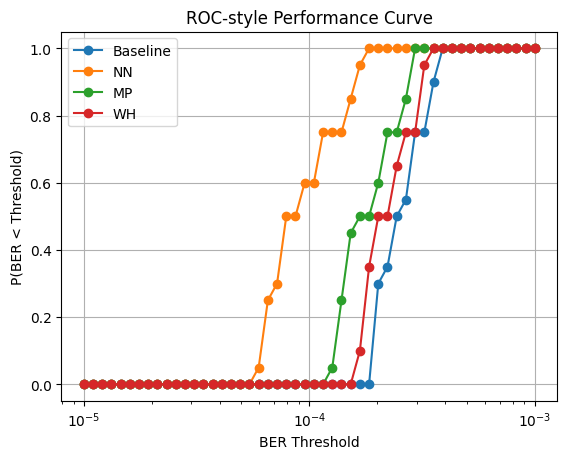

In [8]:
# ==============================
# ROC-LIKE CURVE (Threshold Sweep)
# ==============================

thresholds = np.logspace(-5, -3, 50)  # from 1e-5 to 1e-3

plt.figure()

for case, df in dfs.items():

    probs = []

    for th in thresholds:
        success = (df["BER"] < th).mean()
        probs.append(success)

    plt.plot(thresholds, probs, marker='o', label=case)

plt.xscale("log")
plt.xlabel("BER Threshold")
plt.ylabel("P(BER < Threshold)")
plt.title("ROC-style Performance Curve")
plt.grid(True)
plt.legend()
plt.show()

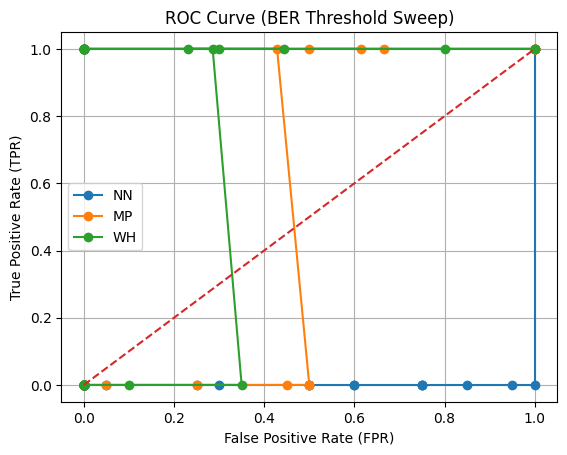

In [9]:
# ==============================
# TRUE ROC CURVE (TPR vs FPR)
# ==============================

import numpy as np
import matplotlib.pyplot as plt

# Define thresholds (log-scale is important for BER)
thresholds = np.logspace(-5, -3, 50)

baseline = dfs["Baseline"]

plt.figure()

for method in ["NN", "MP", "WH"]:

    df_method = dfs[method]

    TPR_list = []
    FPR_list = []

    for th in thresholds:

        # Ground truth (Baseline)
        true_good = baseline["BER"] < th
        true_bad  = baseline["BER"] >= th

        # Predictions (Method)
        pred_good = df_method["BER"] < th
        pred_bad  = df_method["BER"] >= th

        # Confusion matrix
        TP = np.sum(pred_good & true_good)
        FP = np.sum(pred_good & true_bad)
        FN = np.sum(pred_bad & true_good)
        TN = np.sum(pred_bad & true_bad)

        # Rates
        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        TPR_list.append(TPR)
        FPR_list.append(FPR)

    # Plot ROC curve
    plt.plot(FPR_list, TPR_list, marker='o', label=method)

# Random classifier reference
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve (BER Threshold Sweep)")
plt.grid(True)
plt.legend()
plt.show()